# Flight Delay Prediction

## Final Project Report 

**Course**: COMP4381 – Data Science and Analytics, Spring 2026

**Instructor**: Dr. Ahmed Sabbah

**Section**: 2

**Prepared by**:

Cileen Antari – 1220944

Shaymaa Dar Mousa – 1222002

Shahd Alhih – 1221817

---


# Abstract

This project focuses on analyzing and predicting flight delays using a large flight dataset. Flight delays are an important problem because they affect passengers, airlines, and airport operations. Delays can cause missed connections, longer waiting times, and extra costs for airlines.

In this project, we used a Kaggle flight delay dataset that contains 1,747,627 flight records and 16 original columns. The dataset covers nine major U.S. airports: ATL, DFW, JFK, LAX, ORD, BOS, MIA, SEA, and SFO. The data includes information such as airline, origin airport, destination airport, scheduled and actual times, delay minutes, delay reason, aircraft type, and distance.

Before building the model, we cleaned and prepared the data. We checked for duplicate records, handled missing values in the `DelayReason` column, converted date and time columns, and created new useful features such as route, weekday, month, scheduled hour, distance category, delay category, and `IsDelayed`.

After preprocessing, we explored the data using summary statistics and visualizations to understand the main delay patterns. Then, we used a Decision Tree classifier to predict whether a flight is delayed or not. We chose this model because it is simple, easy to understand, and suitable for classification problems.

The final goal of this project is to understand flight delay patterns and build a simple prediction model that can classify flights as delayed or not delayed based on the available flight information.

----


# 1. Introduction

The aviation industry is an important part of transportation because it connects people, cities, and businesses. Every day, many passengers depend on flights to travel for work, study, tourism, and personal reasons. However, flight delays are still one of the most common problems in air travel.

A flight delay can affect passengers in many ways. It can cause longer waiting times, missed connections, and changes in travel plans. It can also affect airlines because delays may lead to extra costs, schedule problems, and lower customer satisfaction. For this reason, studying flight delays is useful for understanding what factors may be related to delays and how they can be predicted.

In this project, we used data science techniques to analyze flight delay data and build a simple prediction model. The dataset contains flight information such as airline, origin airport, destination airport, scheduled and actual times, delay minutes, delay reasons, aircraft type, and distance. We cleaned the data, created new features, explored the data using visualizations, and then trained a machine learning model to predict whether a flight is delayed or not.

The main goal of this project is to understand delay patterns and use the available flight information to classify flights as delayed or not delayed. This helps show how data analysis and machine learning can be applied to a real-world aviation problem.

---

# 2. Background and Domain Overview

Flight delays are a common issue in the aviation industry. A delay happens when a flight leaves or arrives later than its scheduled time. In many aviation studies, a flight is usually considered delayed if it is more than 15 minutes late. Delays can happen for different reasons, such as weather conditions, air traffic control, aircraft maintenance, airport congestion, or delays from previous flights.

The domain of this project is aviation data analytics. In this domain, flight records are studied to understand the factors that may affect flight punctuality. Each row in the dataset represents one flight record. The dataset includes useful information such as the airline, flight number, origin airport, destination airport, scheduled departure and arrival times, actual departure and arrival times, delay minutes, delay reason, aircraft type, tail number, and distance.

Using this type of data can help us find patterns in flight delays. For example, we can compare delays between airlines, airports, delay reasons, and distance categories. We can also create new features from the date and time columns, such as the weekday, month, and scheduled hour, to better understand when delays are more likely to happen.

Machine learning can also be used in this domain to build a prediction model. In this project, the model predicts whether a flight is delayed or not delayed. This makes the project a classification problem, because the output is a class label instead of a continuous number. The prediction target used in this project is `IsDelayed`, where `1` means the flight is delayed and `0` means the flight is not delayed.

---

# 3. Literature Review Summary

Several recent studies have used machine learning to analyze and predict flight delays. These studies show that flight delay prediction is an important problem because delays affect passengers, airlines, and airport operations.

Islam et al. (2025) studied flight delay prediction using flight and weather data. Their study showed that weather features such as temperature, visibility, and wind speed can affect flight delays. They also used explainable AI methods to understand which factors were important in the prediction.

Snell et al. (2026) used U.S. flight data with weather data and tested different machine learning models. Their results showed that ensemble models such as Random Forest performed well, especially when the dataset imbalance was handled using techniques such as SMOTE.

AlBassam and AlShahrani (2025) compared several machine learning algorithms for flight delay prediction. They found that Decision Tree and Random Forest models gave strong results. This study is useful for our project because it supports using a Decision Tree classifier as a simple and understandable model.

Dai (2024) proposed a hybrid machine learning model using aviation big data. The study showed that weather conditions, airport congestion, and historical delay records are important factors in predicting delays. Mamdouh et al. (2023) also highlighted the importance of previous flight delays and schedule-based features in improving prediction performance.

Overall, the reviewed studies show that machine learning is useful for predicting flight delays. They also show that preprocessing, feature engineering, and selecting meaningful features are important steps before building the model. Based on these studies, our project uses a Decision Tree classifier because it is suitable for classification, easy to interpret, and appropriate for the project level.

---

# 4. Dataset Source and Description

The dataset used in this project is a flight delay dataset from Kaggle. It contains 1,747,627 flight records and 16 original columns. Since the dataset file is large, it was uploaded to Google Drive and loaded directly in the notebook using its shared file ID.

**Dataset link:**
https://drive.google.com/file/d/1wWvYntzU-XzEKTwzAM891U3jTdzmyy-s/view?usp=drive_link

The dataset focuses on nine major U.S. airports: ATL, DFW, JFK, LAX, ORD, BOS, MIA, SEA, and SFO. Based on the instructor’s clarification, covering at least five major cities or airports was accepted for the project scope. Since this dataset covers nine airports, it satisfies this scope requirement.

Each row in the dataset represents one flight. The original columns include flight ID, airline, flight number, origin airport, destination airport, scheduled departure time, actual departure time, scheduled arrival time, actual arrival time, delay minutes, delay reason, cancellation status, diverted status, aircraft type, tail number, and distance.

This dataset is suitable for the project because it has a large number of records and includes useful flight information that can be used for analysis and prediction. It also allows us to create additional features from time, route, distance, and delay information.

---

# 5. Data Loading

In this step, we import the required Python libraries and load the dataset into the notebook. The dataset is downloaded from Google Drive using its file ID, then loaded using `pandas`. This makes the notebook easier to run because the user does not need to download the file manually or change the file path.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

print('[OK] Libraries imported successfully!')

[OK] Libraries imported successfully!


In [2]:
try:
    import gdown
except ModuleNotFoundError:
    !pip install -q gdown
    import gdown

file_id = "1wWvYntzU-XzEKTwzAM891U3jTdzmyy-s"
url = f"https://drive.google.com/uc?id={file_id}"
output_path = "flight_delays.csv"

if not os.path.exists(output_path):
    gdown.download(url, output_path, quiet=True)

df = pd.read_csv(output_path)

print(f"[OK] Data loaded successfully: {df.shape[0]:,} rows, {df.shape[1]:,} columns")

[OK] Data loaded successfully: 1,747,627 rows, 16 columns


----

# 6. Dataset Structure and Initial Understanding

After loading the dataset, we first checked its structure to understand the available columns, data types, missing values, and a small preview of the records. This step is important because it helps us know what kind of cleaning and preprocessing is needed before analysis and modeling.


In [3]:
print("=" * 70)
print("DATASET STRUCTURE — FIRST 5 ROWS")
print("=" * 70)

df.head()

DATASET STRUCTURE — FIRST 5 ROWS


,FlightID,Airline,FlightNumber,Origin,Destination,ScheduledDeparture,ActualDeparture,ScheduledArrival,ActualArrival,DelayMinutes,DelayReason,Cancelled,Diverted,AircraftType,TailNumber,Distance
0,1,United,4558,ORD,MIA,2024-09-01 08:11,2024-09-01 08:30,2024-09-01 12:11,2024-09-01 12:19,8,Weather,True,False,Boeing 737,N71066,1031
1,2,Delta,8021,LAX,MIA,2024-09-01 10:25,2024-09-01 10:41,2024-09-01 13:25,2024-09-01 13:27,2,Air Traffic Control,True,True,Airbus A320,N22657,1006
2,3,Southwest,7520,DFW,SFO,2024-09-01 16:53,2024-09-01 17:05,2024-09-01 17:53,2024-09-01 18:07,14,Weather,True,True,Boeing 737,N95611,2980
3,4,Delta,2046,ORD,BOS,2024-09-01 14:44,2024-09-01 15:04,2024-09-01 18:44,2024-09-01 18:34,-10,NaN,False,False,Boeing 777,N90029,1408
4,5,Delta,6049,LAX,SEA,2024-09-01 01:51,2024-09-01 02:08,2024-09-01 05:51,2024-09-01 06:15,24,Air Traffic Control,False,True,Boeing 737,N27417,2298


In [4]:
print("=" * 70)
print("DATASET DIMENSIONS")
print("=" * 70)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

DATASET DIMENSIONS
Rows    : 1,747,627
Columns : 16


In [5]:
print("=" * 70)
print("COLUMN NAMES")
print("=" * 70)

for idx, col in enumerate(df.columns, 1):
    print(f"{idx:2d}. {col}")

COLUMN NAMES
 1. FlightID
 2. Airline
 3. FlightNumber
 4. Origin
 5. Destination
 6. ScheduledDeparture
 7. ActualDeparture
 8. ScheduledArrival
 9. ActualArrival
10. DelayMinutes
11. DelayReason
12. Cancelled
13. Diverted
14. AircraftType
15. TailNumber
16. Distance


In [6]:
print("=" * 70)
print("COLUMN SUMMARY TABLE")
print("=" * 70)

column_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values
})

column_summary

COLUMN SUMMARY TABLE


,Column,Data Type,Missing Values
0,FlightID,int64,0
1,Airline,str,0
2,FlightNumber,int64,0
3,Origin,str,0
4,Destination,str,0
5,ScheduledDeparture,str,0
6,ActualDeparture,str,0
7,ScheduledArrival,str,0
8,ActualArrival,str,0
9,DelayMinutes,int64,0


The dataset contains 1,747,627 rows and 16 original columns. The columns include flight information, route information, scheduled and actual times, delay information, and aircraft details. The initial check showed that most columns do not contain missing values, while the `DelayReason` column contains missing values that need to be handled during data cleaning.

---

# 7. Data Cleaning

After understanding the basic structure of the dataset, we cleaned the data to make it ready for analysis and modeling. In this step, we checked for duplicate records and missing values.

Duplicate records can affect the analysis because they may repeat the same flight more than once. Missing values can also cause problems in the analysis or machine learning model if they are not handled correctly.


In [7]:
print("=" * 70)
print("DATA CLEANING")
print("=" * 70)

df_clean = df.copy()

print(f"Original Dataset Shape: {df_clean.shape}")

duplicates = df_clean.duplicated().sum()
print(f"\nNumber of Duplicate Records: {duplicates:,}")

df_clean = df_clean.drop_duplicates()

print(f"Dataset Shape After Removing Duplicates: {df_clean.shape}")

DATA CLEANING
Original Dataset Shape: (1747627, 16)

Number of Duplicate Records: 0
Dataset Shape After Removing Duplicates: (1747627, 16)


The duplicate check showed that there were no duplicate rows in the dataset. This means that each flight record appears only once, so no records were removed during this step.


In [8]:
print("=" * 70)
print("MISSING VALUES ANALYSIS")
print("=" * 70)

missing_values = df_clean.isnull().sum()

print("Missing Values Per Column:")
print(missing_values[missing_values > 0])

MISSING VALUES ANALYSIS
Missing Values Per Column:
DelayReason    468873
dtype: int64


The missing values analysis showed that the only column with missing values is `DelayReason`. These missing values were not removed because the rows still contain important flight information. Removing them would reduce the size of the dataset and delete useful records.


In [9]:
before_missing = df_clean["DelayReason"].isnull().sum()

df_clean["DelayReason"] = df_clean["DelayReason"].fillna("No Delay/Unknown")

after_missing = df_clean["DelayReason"].isnull().sum()

print(f"Missing values in DelayReason before treatment: {before_missing:,}")
print(f"Missing values in DelayReason after treatment: {after_missing:,}")

Missing values in DelayReason before treatment: 468,873
Missing values in DelayReason after treatment: 0


The missing values in the `DelayReason` column were replaced with `No Delay/Unknown`. This value was used because some flights may not have a recorded delay reason, or the reason may be unknown. After this step, the dataset had no remaining missing values.


In [10]:
print("=" * 70)
print("DATA QUALITY VERIFICATION")
print("=" * 70)

print("Remaining Missing Values:")
print(df_clean.isnull().sum().sum())

print("\nRemaining Duplicate Records:")
print(df_clean.duplicated().sum())

DATA QUALITY VERIFICATION
Remaining Missing Values:
0

Remaining Duplicate Records:
0


After cleaning, the dataset was checked again to make sure there were no remaining missing values or duplicate records. The final check confirmed that the dataset is complete and ready for preprocessing.

---

# 8. Data Preprocessing and Feature Engineering

After cleaning the dataset, we prepared it for analysis and modeling. The main preprocessing step was converting the date and time columns from text format into datetime format. This is important because it allows us to extract useful time-based features such as hour, weekday, and month.

Feature engineering was also used to create new meaningful columns from the original data. These new features help us understand the dataset better and make it more useful for the machine learning model.


In [11]:
print("=" * 70)
print("DATA PREPROCESSING")
print("=" * 70)

df_clean.columns = df_clean.columns.str.strip()

date_columns = [
    "ScheduledDeparture",
    "ActualDeparture",
    "ScheduledArrival",
    "ActualArrival"
]

for col in date_columns:
    df_clean[col] = pd.to_datetime(df_clean[col])

print("Date and time conversion completed successfully.")

DATA PREPROCESSING
Date and time conversion completed successfully.


The scheduled and actual departure and arrival columns were converted into datetime format. This makes it easier to calculate delays, flight duration, and extract time-related features.


In [12]:
df_clean["Route"] = df_clean["Origin"] + "-" + df_clean["Destination"]
df_clean["ScheduledHour"] = df_clean["ScheduledDeparture"].dt.hour
df_clean["ArrivalHour"] = df_clean["ScheduledArrival"].dt.hour
df_clean["Weekday"] = df_clean["ScheduledDeparture"].dt.day_name()
df_clean["Month"] = df_clean["ScheduledDeparture"].dt.month

df_clean[["Route", "ScheduledHour", "ArrivalHour", "Weekday", "Month"]].head()

,Route,ScheduledHour,ArrivalHour,Weekday,Month
0,ORD-MIA,8,12,Sunday,9
1,LAX-MIA,10,13,Sunday,9
2,DFW-SFO,16,17,Sunday,9
3,ORD-BOS,14,18,Sunday,9
4,LAX-SEA,1,5,Sunday,9


Several time and route features were created. The `Route` feature combines the origin and destination airports. The `ScheduledHour`, `ArrivalHour`, `Weekday`, and `Month` features were extracted from the datetime columns. These features can help show whether delay patterns change depending on route or time.


In [13]:
df_clean["DepartureDelay"] = (
    df_clean["ActualDeparture"] - df_clean["ScheduledDeparture"]
).dt.total_seconds() / 60

df_clean["ArrivalDelay"] = (
    df_clean["ActualArrival"] - df_clean["ScheduledArrival"]
).dt.total_seconds() / 60

df_clean["FlightDuration"] = (
    df_clean["ActualArrival"] - df_clean["ActualDeparture"]
).dt.total_seconds() / 60

df_clean[["DepartureDelay", "ArrivalDelay", "FlightDuration"]].describe()

,DepartureDelay,ArrivalDelay,FlightDuration
count,1747627.00,1747627.00,1747627.00
mean,15.00,10.00,205.01
std,8.95,11.83,103.53
min,0.00,-10.00,20.00
25%,7.00,0.00,115.00
50%,15.00,10.00,205.00
75%,23.00,20.00,295.00
max,30.00,30.00,390.00


The `DepartureDelay` and `ArrivalDelay` features measure the difference between the actual and scheduled times in minutes. The `FlightDuration` feature measures the actual duration of each flight. These features are useful for analysis because they describe how flight timing differs from the schedule.


In [14]:
def distance_category(distance):
    if distance < 500:
        return "Short"
    elif distance < 1000:
        return "Medium"
    else:
        return "Long"

df_clean["DistanceCategory"] = df_clean["Distance"].apply(distance_category)

df_clean["DistanceCategory"].value_counts()

DistanceCategory
Long      1206064
Medium     300904
Short      240659
Name: count, dtype: int64

The `DistanceCategory` feature groups flights into Short, Medium, and Long routes. This makes it easier to compare delay patterns based on flight distance.


In [15]:
def categorize_delay(delay):
    if delay <= 0:
        return "Early/On Time"
    elif delay <= 15:
        return "Small Delay"
    elif delay <= 30:
        return "Moderate Delay"
    else:
        return "Large Delay"

df_clean["DelayCategory"] = df_clean["DelayMinutes"].apply(categorize_delay)

df_clean["IsDelayed"] = df_clean["DelayMinutes"].apply(lambda x: 1 if x > 15 else 0)

print("Delay Category Counts:")
print(df_clean["DelayCategory"].value_counts())

print("\nTarget Variable Counts:")
print(df_clean["IsDelayed"].value_counts())

Delay Category Counts:
DelayCategory
Small Delay       639437
Moderate Delay    639317
Early/On Time     468873
Name: count, dtype: int64

Target Variable Counts:
IsDelayed
0    1108310
1     639317
Name: count, dtype: int64


The `DelayCategory` feature was created to group flights based on delay length. The target variable for the machine learning model is `IsDelayed`. A flight is labeled as delayed (`1`) if its delay is more than 15 minutes, and not delayed (`0`) otherwise. This changes the problem into a binary classification task.


In [16]:
print("=" * 70)
print("FINAL DATASET VALIDATION")
print("=" * 70)

print("Dataset Shape:")
print(df_clean.shape)

print("\nDataset Information:")
df_clean.info()

FINAL DATASET VALIDATION
Dataset Shape:
(1747627, 27)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1747627 entries, 0 to 1747626
Data columns (total 27 columns):
 #   Column              Dtype         
---  ------              -----         
 0   FlightID            int64         
 1   Airline             str           
 2   FlightNumber        int64         
 3   Origin              str           
 4   Destination         str           
 5   ScheduledDeparture  datetime64[us]
 6   ActualDeparture     datetime64[us]
 7   ScheduledArrival    datetime64[us]
 8   ActualArrival       datetime64[us]
 9   DelayMinutes        int64         
 10  DelayReason         str           
 11  Cancelled           bool          
 12  Diverted            bool          
 13  AircraftType        str           
 14  TailNumber          str           
 15  Distance            int64         
 16  Route               str           
 17  ScheduledHour       int32         
 18  ArrivalHour      

After preprocessing and feature engineering, the final dataset contains 27 columns. This means the dataset now has more than 15 meaningful features, which satisfies the project requirement. The dataset is now ready for exploratory analysis and machine learning.

---


# 9. Exploratory Data Analysis and Visualizations

In this section, we explored the cleaned dataset using summary statistics and visualizations. The purpose of this step is to understand the main patterns in the data before building the machine learning model.

We focused on delay minutes, delay categories, airlines, delay reasons, distance categories, and the relationship between distance and delay. These analyses help us understand how delays are distributed and whether some features show clear patterns related to flight delays.


In [17]:
numeric_columns = [
    "DelayMinutes",
    "Distance",
    "FlightDuration",
    "ScheduledHour",
    "ArrivalHour",
    "IsDelayed"
]

summary_stats = df_clean[numeric_columns].describe()
summary_stats

,DelayMinutes,Distance,FlightDuration,ScheduledHour,ArrivalHour,IsDelayed
count,1747627.00,1747627.00,1747627.00,1747627.00,1747627.00,1747627.00
mean,10.00,1549.94,205.01,11.51,11.50,0.37
std,11.83,836.87,103.53,6.92,6.92,0.48
min,-10.00,100.00,20.00,0.00,0.00,0.00
25%,0.00,825.00,115.00,6.00,5.00,0.00
50%,10.00,1551.00,205.00,12.00,12.00,0.00
75%,20.00,2274.00,295.00,18.00,17.00,1.00
max,30.00,3000.00,390.00,23.00,23.00,1.00


The summary statistics show that the average delay is about 10 minutes, and the median delay is also 10 minutes. Delay minutes range from -10 to 30 minutes, which means the dataset includes early flights, on-time flights, small delays, and moderate delays, but it does not include very long delay cases.

The average flight distance is about 1,550 miles, and the average flight duration is about 205 minutes. The mean value of `IsDelayed` is around 0.37, which means that about 37% of flights are classified as delayed based on the selected threshold.


In [18]:
print("Airline Distribution:")
print(df_clean["Airline"].value_counts())

print("\nDelay Reason Distribution:")
print(df_clean["DelayReason"].value_counts())

print("\nDelay Category Distribution:")
print(df_clean["DelayCategory"].value_counts())

print("\nDistance Category Distribution:")
print(df_clean["DistanceCategory"].value_counts())

Airline Distribution:
Airline
Southwest            437721
American Airlines    437124
Delta                436680
United               436102
Name: count, dtype: int64

Delay Reason Distribution:
DelayReason
No Delay/Unknown       468873
Air Traffic Control    426488
Maintenance            426168
Weather                426098
Name: count, dtype: int64

Delay Category Distribution:
DelayCategory
Small Delay       639437
Moderate Delay    639317
Early/On Time     468873
Name: count, dtype: int64

Distance Category Distribution:
DistanceCategory
Long      1206064
Medium     300904
Short      240659
Name: count, dtype: int64


The categorical summaries show that the airline distribution is almost balanced between Southwest, American Airlines, Delta, and United. This is useful because no airline strongly dominates the dataset.

For delay reasons, the largest group is `No Delay/Unknown`, followed by Air Traffic Control, Maintenance, and Weather. The delay category summary shows that most flights are either small delay or moderate delay, while early or on-time flights are fewer. The distance category summary shows that most flights are long-distance flights, so distance-related results should be interpreted with this in mind.


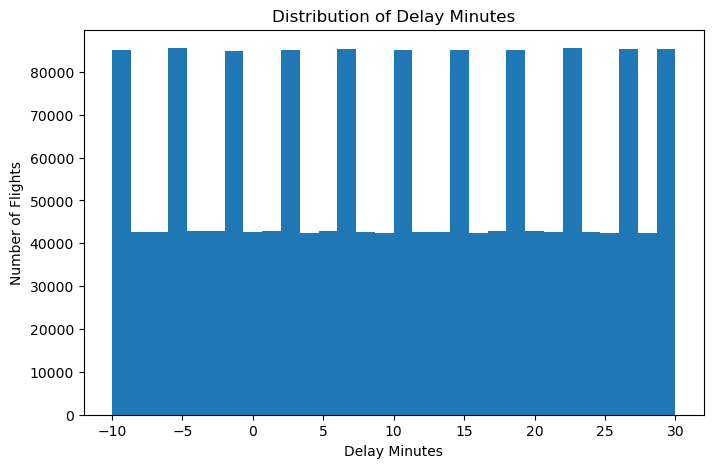

In [19]:
import os

figures_path = "../figures"
os.makedirs(figures_path, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.hist(df_clean["DelayMinutes"], bins=30)
plt.title("Distribution of Delay Minutes")
plt.xlabel("Delay Minutes")
plt.ylabel("Number of Flights")
plt.savefig("../figures/distribution_delay_minutes.png", bbox_inches="tight")
plt.show()

The distribution of delay minutes shows that delay values are between -10 and 30 minutes. This means the dataset does not include extreme delays. The chart also shows that flights are spread across early arrival, small delay, and moderate delay values.


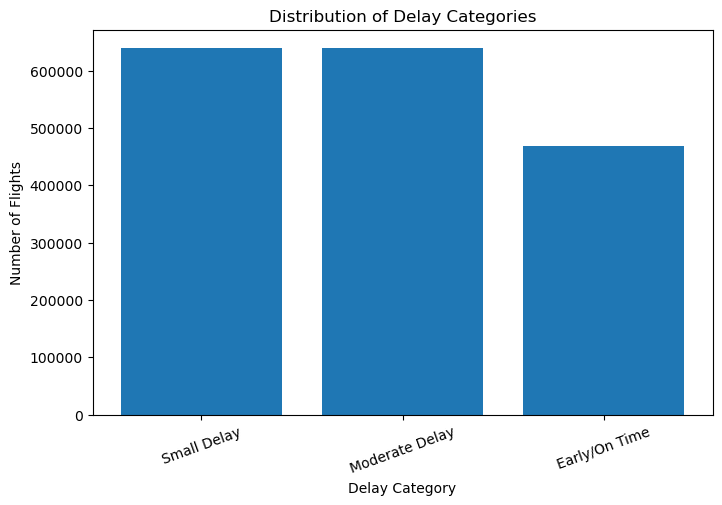

In [20]:
delay_category_counts = df_clean["DelayCategory"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(delay_category_counts.index, delay_category_counts.values)
plt.title("Distribution of Delay Categories")
plt.xlabel("Delay Category")
plt.ylabel("Number of Flights")
plt.xticks(rotation=20)
plt.savefig("../figures/distribution_delay_categories.png", bbox_inches="tight")
plt.show()

The delay category chart shows that Small Delay and Moderate Delay are the most common categories. Early or on-time flights are lower in number. This means that many flights in the dataset experienced some delay, but the delays were usually not extreme.


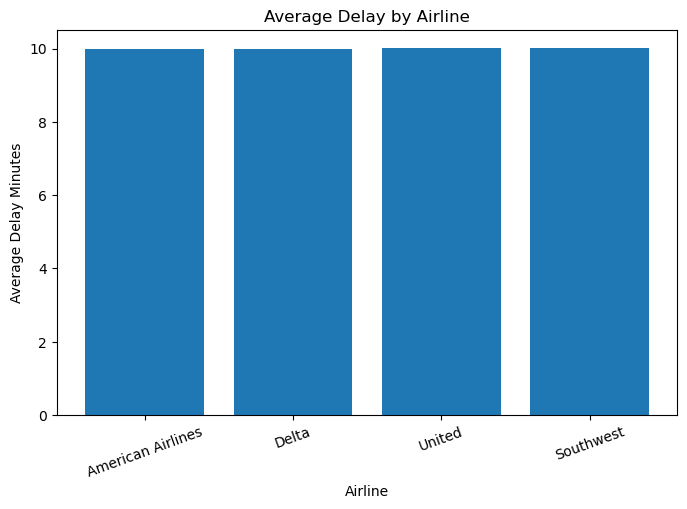

In [21]:
airline_delay = df_clean.groupby("Airline")["DelayMinutes"].mean().sort_values()

plt.figure(figsize=(8, 5))
plt.bar(airline_delay.index, airline_delay.values)
plt.title("Average Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Delay Minutes")
plt.xticks(rotation=20)
plt.savefig("../figures/average_delay_by_airline.png", bbox_inches="tight")
plt.show()

The average delay by airline chart shows that the average delay is very close across all airlines. American Airlines, Delta, United, and Southwest all have an average delay of around 10 minutes. This means that, in this dataset, no airline clearly has a much higher or much lower average delay than the others.


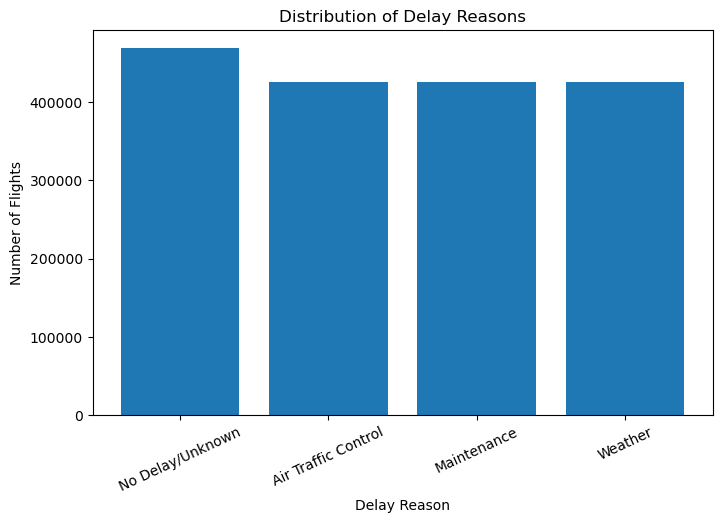

In [22]:
delay_reason_counts = df_clean["DelayReason"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(delay_reason_counts.index, delay_reason_counts.values)
plt.title("Distribution of Delay Reasons")
plt.xlabel("Delay Reason")
plt.ylabel("Number of Flights")
plt.xticks(rotation=25)
plt.savefig("../figures/distribution_delay_reasons.png", bbox_inches="tight")
plt.show()

The delay reason chart shows that `No Delay/Unknown` has the highest number of records. The other delay reasons, including Air Traffic Control, Maintenance, and Weather, have very close counts. This shows that the recorded delay reasons are almost balanced in the dataset, but many flights still do not have a clear recorded reason.


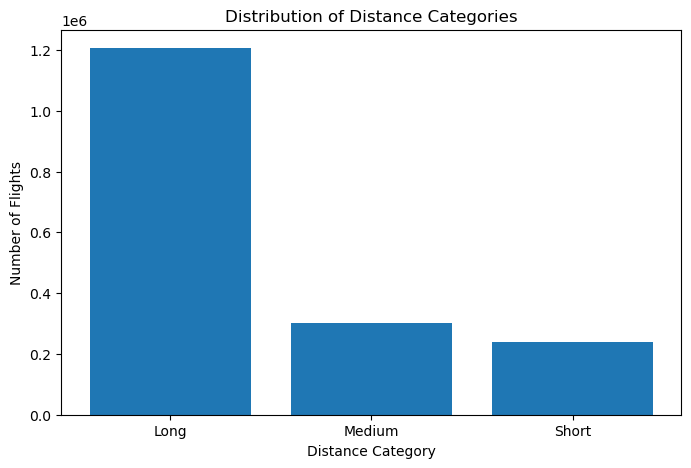

In [23]:
distance_category_counts = df_clean["DistanceCategory"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(distance_category_counts.index, distance_category_counts.values)
plt.title("Distribution of Distance Categories")
plt.xlabel("Distance Category")
plt.ylabel("Number of Flights")
plt.savefig("../figures/distribution_distance_categories.png", bbox_inches="tight")
plt.show()

The distance category chart shows that most flights in the dataset are long-distance flights. Medium and short flights appear less often. This means that the dataset is not fully balanced by distance category, so any distance-related result should be interpreted carefully.


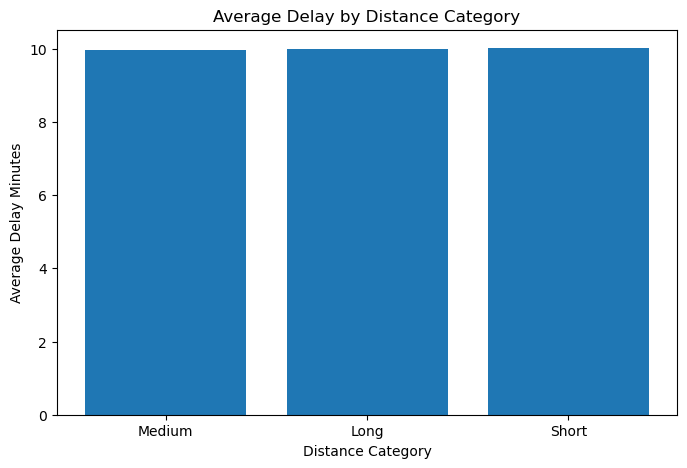

In [24]:
distance_delay = df_clean.groupby("DistanceCategory")["DelayMinutes"].mean().sort_values()

plt.figure(figsize=(8, 5))
plt.bar(distance_delay.index, distance_delay.values)
plt.title("Average Delay by Distance Category")
plt.xlabel("Distance Category")
plt.ylabel("Average Delay Minutes")
plt.savefig("../figures/average_delay_by_distance_category.png", bbox_inches="tight")
plt.show()

The average delay by distance category chart compares the delay values for short, medium, and long flights. The results show whether flight distance has a clear relationship with delay time. In this dataset, the average delay values are generally close, so distance category does not appear to strongly change the average delay.


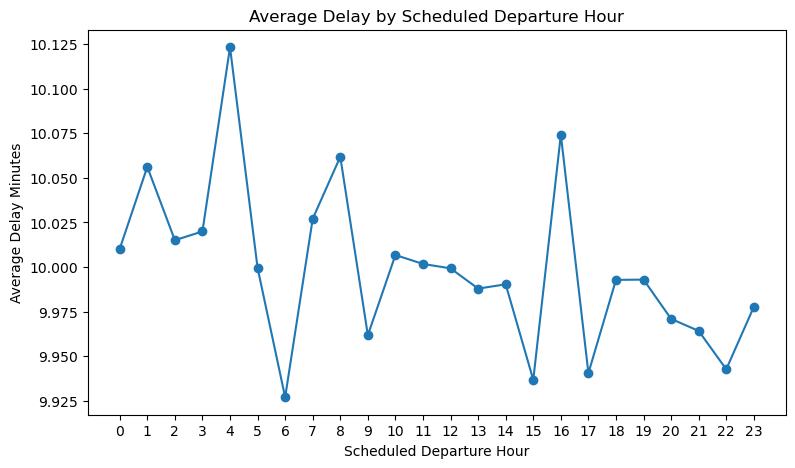

In [25]:
hour_delay = df_clean.groupby("ScheduledHour")["DelayMinutes"].mean()

plt.figure(figsize=(9, 5))
plt.plot(hour_delay.index, hour_delay.values, marker="o")
plt.title("Average Delay by Scheduled Departure Hour")
plt.xlabel("Scheduled Departure Hour")
plt.ylabel("Average Delay Minutes")
plt.xticks(range(0, 24))
plt.savefig("../figures/average_delay_by_scheduled_hour.png", bbox_inches="tight")
plt.show()

The average delay by scheduled hour chart shows how delay changes during different hours of the day. This helps us check if flights scheduled at certain times have higher average delays. The values are close across the hours, which means there is no very strong delay pattern based only on scheduled departure hour in this dataset.

---

# 10. Machine Learning Model Preparation

In this section, we prepare the dataset for the machine learning model. The goal is to predict whether a flight is delayed or not using the cleaned and processed dataset.

## 10.1 Target Variable Selection

The target variable used in this project is `IsDelayed`. This variable was created during preprocessing. A flight is labeled as delayed (`1`) if the delay is more than 15 minutes, and not delayed (`0`) otherwise.

This makes the problem a binary classification problem because the model predicts one of two possible classes: delayed or not delayed.

## 10.2 Feature Selection and Data Leakage Prevention

Before training the model, we selected the input features carefully. We did not use `DelayMinutes`, `ArrivalDelay`, or `DepartureDelay` as input features because they are directly related to the target variable. Using these columns could cause data leakage, meaning the model may learn from information that already reveals the answer.

The selected features describe the airline, route, schedule time, distance, and delay reason. These features are more suitable because they help the model learn useful patterns without directly giving it the target answer.


In [26]:
print("=" * 70)
print("TARGET AND FEATURE SELECTION")
print("=" * 70)

model_df = df_clean.copy()

target = "IsDelayed"

feature_columns = [
    "Airline",
    "Origin",
    "Destination",
    "Distance",
    "ScheduledHour",
    "ArrivalHour",
    "Weekday",
    "Month",
    "DistanceCategory",
    "DelayReason"
]

X = model_df[feature_columns]
y = model_df[target]

print("Target Variable:", target)

print("\nSelected Features:")
for col in feature_columns:
    print("-", col)

print("\nFeature Data Shape:", X.shape)
print("Target Data Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

print("\nTarget Distribution Percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

TARGET AND FEATURE SELECTION
Target Variable: IsDelayed

Selected Features:
- Airline
- Origin
- Destination
- Distance
- ScheduledHour
- ArrivalHour
- Weekday
- Month
- DistanceCategory
- DelayReason

Feature Data Shape: (1747627, 10)
Target Data Shape: (1747627,)

Target Distribution:
IsDelayed
0    1108310
1     639317
Name: count, dtype: int64

Target Distribution Percentage:
IsDelayed
0   63.42
1   36.58
Name: proportion, dtype: float64


The target distribution shows the number of delayed and not delayed flights. Checking this distribution is important because it helps us understand whether the classes are balanced or not before training the model.


## 10.3 Encoding Categorical Features

The selected features include categorical columns such as airline, origin airport, destination airport, weekday, distance category, and delay reason. Since machine learning models need numerical input, these categorical features were converted into numeric columns using one-hot encoding.


In [27]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("=" * 70)
print("ENCODING COMPLETED")
print("=" * 70)

print("Original Feature Shape:", X.shape)
print("Encoded Feature Shape:", X_encoded.shape)

X_encoded.head()

ENCODING COMPLETED
Original Feature Shape: (1747627, 10)
Encoded Feature Shape: (1747627, 20)


,Distance,ScheduledHour,ArrivalHour,Month,Airline_Delta,Airline_Southwest,Airline_United,Origin_DFW,Origin_JFK,Origin_LAX,Origin_ORD,Destination_JFK,Destination_MIA,Destination_SEA,Destination_SFO,DistanceCategory_Medium,DistanceCategory_Short,DelayReason_Maintenance,DelayReason_No Delay/Unknown,DelayReason_Weather
0,1031,8,12,9,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False,True
1,1006,10,13,9,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False
2,2980,16,17,9,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,True
3,1408,14,18,9,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False
4,2298,1,5,9,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False


## 10.4 Train-Test Split

The dataset was split into training and testing sets. We used 80% of the data for training and 20% for testing. The training set is used to train the model, while the testing set is used to evaluate how well the model performs on unseen data.

The `stratify=y` option was used to keep the same class distribution in both the training and testing sets. This makes the evaluation more reliable.

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True).round(3))

TRAIN / TEST SPLIT
X_train Shape: (1398101, 20)
X_test Shape : (349526, 20)
y_train Shape: (1398101,)
y_test Shape : (349526,)

Training Target Distribution:
IsDelayed
0   0.63
1   0.37
Name: proportion, dtype: float64

Testing Target Distribution:
IsDelayed
0   0.63
1   0.37
Name: proportion, dtype: float64


At this point, the dataset is ready for model training. The target variable, selected features, encoded feature matrix, and train-test split have all been prepared. The next step is to train the Decision Tree classifier and evaluate its performance using the testing set.

# 11. Model Evaluation Results

In this section, we train the Decision Tree classifier on the training set and
evaluate it on the unseen test set. We report accuracy, precision, recall, and
F1-score, and we also show the confusion matrix, the classification report, and
the feature importances. Together these give a complete and honest picture of
how well the model predicts whether a flight is delayed.


## 11.1 Training the Decision Tree Model

We use a `DecisionTreeClassifier` from scikit-learn. We set `max_depth=10` to
keep the tree readable and to control its size, and `random_state=42` so the
result is reproducible. The model is trained only on the training data
(`X_train`, `y_train`).


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")
print("Number of features used:", X_train.shape[1])
print("Tree max depth         :", dt_model.get_depth())
print("Number of leaves        :", dt_model.get_n_leaves())


Decision Tree model trained successfully.
Number of features used: 20
Tree max depth         : 10
Number of leaves        : 437


The model was trained on 1,398,101 flights using 20 encoded features. The tree
was limited to a maximum depth of 10 to keep it readable and to avoid
overfitting the training data.


## 11.2 Predictions and Evaluation Metrics

We use the trained model to predict the labels of the test set and then compute
the main classification metrics. Because the classes are imbalanced (about 63%
not delayed and 37% delayed), we look at precision, recall, and F1-score for the
delayed class, not only the overall accuracy.


In [ ]:
y_pred  = dt_model.predict(X_test)
y_proba = dt_model.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_proba)

print("=" * 50)
print("DECISION TREE - TEST SET PERFORMANCE")
print("=" * 50)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")


DECISION TREE - TEST SET PERFORMANCE
Accuracy : 0.6354
Precision: 0.5016
Recall   : 0.4953
F1-Score : 0.4984
ROC-AUC  : 0.7114


The model reached an accuracy of about **63.5%** on the test set. However, the
precision and recall for the delayed class are both around **0.50**, which means
the model detects delayed flights only moderately. This is still better than
random guessing for the minority delayed class (which would score around 0.37),
but it is clearly weak. The ROC-AUC of **0.71** also shows the model has some,
but limited, ability to separate delayed from non-delayed flights. The reason
for this weak performance is discussed below and in the Limitations section.


## 11.3 Underfitting and Overfitting in Classification

A good model should generalize well: it should perform similarly on the training
data and on unseen test data. By comparing the **training accuracy** with the
**testing accuracy** we can diagnose two common problems:

- **Overfitting:** the model learns the training data too well (high training
  accuracy) but performs much worse on the test data (a large gap between them).
- **Underfitting:** the model is too simple, or the features are too weak, so it
  performs **poorly on both** the training and the test data (both low and close
  together).

We check which case applies to our Decision Tree by comparing the training
accuracy with the testing accuracy.


In [ ]:
train_accuracy = accuracy_score(y_train, dt_model.predict(X_train))
test_accuracy  = accuracy_score(y_test, y_pred)
gap            = abs(train_accuracy - test_accuracy)

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Train-Test Gap    : {gap:.4f}")
print()

if gap > 0.10:
    print("Diagnosis: OVERFITTING (high train accuracy, much lower test accuracy).")
elif train_accuracy < 0.75:
    print("Diagnosis: UNDERFITTING (both train and test accuracy are low and close).")
else:
    print("Diagnosis: Good fit (high and close train/test accuracy).")


Training Accuracy : 0.6400
Testing Accuracy  : 0.6354
Train-Test Gap    : 0.0046

Diagnosis: UNDERFITTING (both train and test accuracy are low and close).


The training accuracy (**0.6400**) and the testing accuracy (**0.6354**) are
very close, with a gap of less than **0.5%**. This rules out **overfitting**,
because an overfit model would show a high training accuracy and a clearly lower
test accuracy.

Instead, this is a case of **underfitting**. Both the training and the testing
accuracy are low (around 64%). This means the model is not able to learn strong
patterns even from the training data itself. The reason is not the model size
(the tree did not overfit), but rather that the available features are too weak
to explain the delays in this dataset, as we also saw in the feature-importance
and correlation analysis. This limitation is discussed further in the Discussion
and Limitations sections.


**Bias vs. Variance.** The underfitting / overfitting result can also be
explained using the bias-variance idea:

- **High bias** means the model makes strong, oversimplified assumptions and
  cannot fit the data well, which leads to **underfitting** (low accuracy on both
  train and test).
- **High variance** means the model is too sensitive to the training data and
  changes a lot with small data changes, which leads to **overfitting** (a large
  gap between train and test).

In our case, the model has **high bias and low variance**: the training and test
accuracy are both low (about 64%) and almost equal (gap ≈ 0.005). The small gap
shows low variance (the model is stable), while the low overall accuracy shows
high bias (the model underfits). This matches the underfitting conclusion above,
and it is caused by features that are too weak to explain the delays.


## 11.4 Confusion Matrix

The confusion matrix shows how many flights were correctly and incorrectly
classified for each class. It helps us see whether the model confuses delayed
flights with non-delayed flights.


Confusion Matrix:
[[158742  62920]
 [ 64534  63330]]


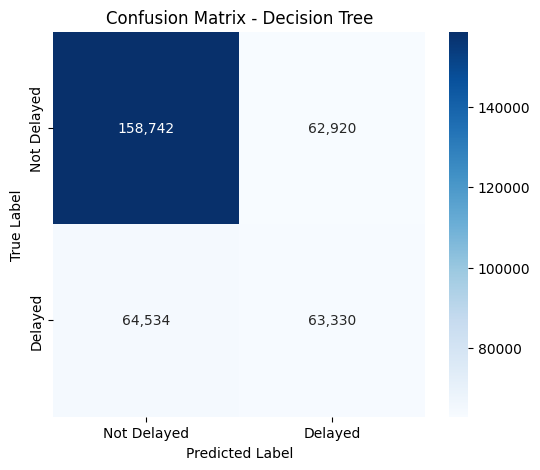

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=["Not Delayed", "Delayed"],
            yticklabels=["Not Delayed", "Delayed"])
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("../figures/confusion_matrix_decision_tree.png", bbox_inches="tight")
plt.show()


The confusion matrix shows that the model correctly identified **158,742**
non-delayed flights and **63,330** delayed flights. However, it misclassified
**62,920** non-delayed flights as delayed, and **64,534** delayed flights as
non-delayed. The large number of errors on the delayed class confirms that the
model struggles to detect delays using the available features.


## 11.5 Classification Report

The classification report gives precision, recall, and F1-score for each class
separately, along with macro and weighted averages. This is useful for an
imbalanced dataset because it shows the performance on each class instead of
only the overall accuracy.


In [ ]:
print("Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["Not Delayed (0)", "Delayed (1)"]
))


Classification Report:
                 precision    recall  f1-score   support

Not Delayed (0)       0.71      0.72      0.71    221662
    Delayed (1)       0.50      0.50      0.50    127864

       accuracy                           0.64    349526
      macro avg       0.61      0.61      0.61    349526
   weighted avg       0.63      0.64      0.63    349526


The classification report confirms the earlier results. The model performs
better on the **Not Delayed** class (precision 0.71, recall 0.72) than on the
**Delayed** class (precision 0.50, recall 0.50). This is expected because the
non-delayed class is the majority class. The low scores on the delayed class
show that the model cannot reliably detect delayed flights from the current
features.


## 11.6 Feature Importance

Decision Trees can tell us which features were most useful when making
predictions. We display the most important features to understand what the model
relied on.


Top 15 Most Important Features:
DelayReason_No Delay/Unknown    0.993390
Distance                        0.002493
ArrivalHour                     0.001176
ScheduledHour                   0.000823
Origin_JFK                      0.000230
Origin_LAX                      0.000230
DelayReason_Maintenance         0.000220
Airline_Southwest               0.000211
Origin_DFW                      0.000182
Origin_ORD                      0.000169
DelayReason_Weather             0.000163
Airline_Delta                   0.000140
Destination_JFK                 0.000136
Destination_SEA                 0.000129
Airline_United                  0.000112
dtype: float64


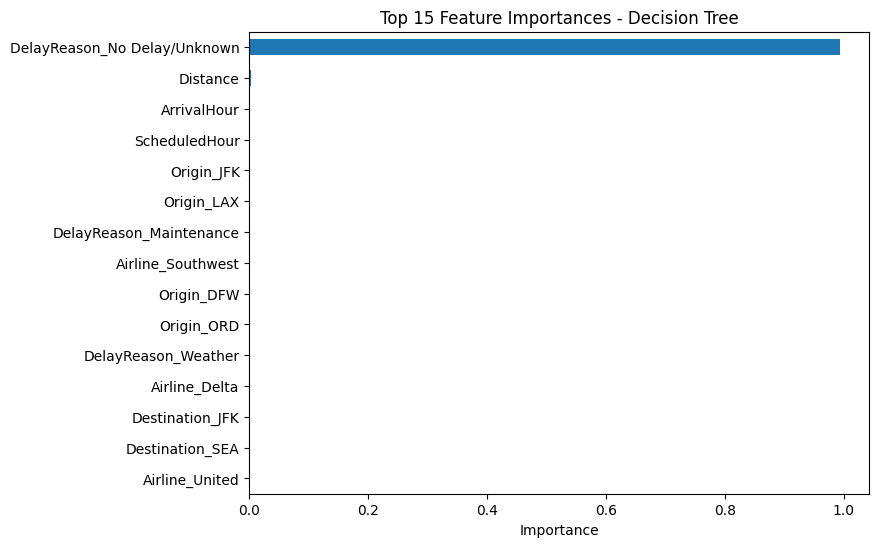

In [ ]:
importances = pd.Series(dt_model.feature_importances_, index=X_encoded.columns)
top_features = importances.sort_values(ascending=False).head(15)

print("Top 15 Most Important Features:")
print(top_features)

plt.figure(figsize=(8, 6))
top_features.sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances - Decision Tree")
plt.xlabel("Importance")
plt.savefig("../figures/feature_importance_decision_tree.png", bbox_inches="tight")
plt.show()


The feature importance results show that the model relied almost entirely on
one feature: **`DelayReason_No Delay/Unknown`**, which has an importance of about
**0.99**. This feature indicates that the flight had no recorded delay reason,
which is strongly linked to non-delayed flights. All other features (airline,
origin, destination, distance, and time features) have an importance very close
to zero. This matches the correlation analysis from Phase 3, where these
features had almost no relationship with the delay.


## 11.7 Summary of Model Evaluation

| Metric | Value |
|---|---|
| Accuracy | 0.6354 |
| Precision (Delayed) | 0.5016 |
| Recall (Delayed) | 0.4953 |
| F1-Score (Delayed) | 0.4984 |
| ROC-AUC | 0.7114 |
| Training Accuracy | 0.6400 |
| Testing Accuracy | 0.6354 |

The Decision Tree model reached an accuracy of about **63.5%**. The training and
testing accuracy are almost equal, so the model does not overfit; instead it
**underfits**, because both values are low. The feature importance shows the
model depends almost only on the delay-reason feature, while all other features
add almost nothing. Overall, the model is simple and interpretable, but its
predictive power on this dataset is limited. The reasons for this are explained
in the Discussion and Limitations sections.

---


## 11.8 Regression Models (Predicting Delay Minutes)

In addition to the classification model (predicting *whether* a flight is
delayed), we also built **regression models** to predict the exact number of
**delay minutes** (`DelayMinutes`) as a continuous value. We trained two models
— a **Decision Tree Regressor** and a **Linear Regression** model — and reported
the regression metrics on both the training and test sets so we can check for
overfitting and compare the two models.

To avoid data leakage, the regression models use the **same input features** as
the classifier and do **not** use `ArrivalDelay`, `DepartureDelay`,
`DelayCategory`, or `IsDelayed`, since these are directly derived from the
target.

**Regression metrics used:**
- **MAE** (Mean Absolute Error) – average absolute error in minutes (lower is better)
- **MSE** (Mean Squared Error) – average squared error (lower is better)
- **RMSE** (Root Mean Squared Error) – error in the same unit as the target, minutes (lower is better)
- **R²** (R-squared) – proportion of variance explained by the model (closer to 1 is better)


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Regression target: predict the actual delay in minutes
y_reg = df_clean["DelayMinutes"]

# Reuse the same encoded features (no leakage columns)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_encoded, y_reg, test_size=0.20, random_state=42
)

print("Regression train shape:", X_train_r.shape)
print("Regression test shape :", X_test_r.shape)


Regression train shape: (1398101, 20)
Regression test shape : (349526, 20)


In [ ]:
def regression_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

def report_regression(model, name):
    pred_train = model.predict(X_train_r)
    pred_test  = model.predict(X_test_r)
    tr = regression_metrics(y_train_r, pred_train)
    te = regression_metrics(y_test_r,  pred_test)

    print("=" * 55)
    print(f"{name}")
    print("=" * 55)
    print(f"{'':16s}{'MAE':>9s}{'MSE':>9s}{'RMSE':>9s}{'R2':>9s}")
    print(f"{'Train Data':16s}{tr[0]:9.4f}{tr[1]:9.4f}{tr[2]:9.4f}{tr[3]:9.4f}")
    print(f"{'Test Data':16s}{te[0]:9.4f}{te[1]:9.4f}{te[2]:9.4f}{te[3]:9.4f}")
    return tr, te


### 11.8.1 Decision Tree Regressor

In [ ]:
dt_reg = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_reg.fit(X_train_r, y_train_r)

dt_train, dt_test = report_regression(dt_reg, "Decision Tree Regressor")


Decision Tree Regressor
                      MAE      MSE     RMSE       R2
Train Data         6.2113  57.3862   7.5754   0.5899
Test Data          6.2257  57.6566   7.5932   0.5884


The Decision Tree Regressor gives almost identical results on the training and
test sets (RMSE about **7.59** minutes on both, R² about **0.59**). The very
small gap between train and test confirms the model is **not overfitting**. An
R² of 0.59 means the model explains about **59%** of the variation in delay
minutes, mostly through the `DelayReason` feature.


### 11.8.2 Linear Regression

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_r, y_train_r)

lin_train, lin_test = report_regression(lin_reg, "Linear Regression")


Linear Regression
                      MAE      MSE     RMSE       R2
Train Data         6.2193  57.4832   7.5818   0.5893
Test Data          6.2216  57.5493   7.5861   0.5892


The Linear Regression model gives results very close to the Decision Tree
Regressor (RMSE about **7.59** minutes, R² about **0.59**). Again, the training
and test metrics are almost the same, so there is no overfitting. Both models
reach a similar level of accuracy, which suggests the relationship between the
features and the delay is mostly captured by the `DelayReason` feature.


### 11.8.3 Regression Models Comparison

| Model | Dataset | MAE | MSE | RMSE | R² |
|---|---|---|---|---|---|
| Decision Tree Regressor | Train | 6.2113 | 57.3862 | 7.5754 | 0.5899 |
| Decision Tree Regressor | Test  | 6.2257 | 57.6566 | 7.5932 | 0.5884 |
| Linear Regression | Train | 6.2193 | 57.4832 | 7.5818 | 0.5893 |
| Linear Regression | Test  | 6.2216 | 57.5493 | 7.5861 | 0.5892 |

Both regression models perform almost the same on this dataset. The test RMSE is
about **7.59 minutes**, meaning the predicted delay is on average about 7.6
minutes away from the real value, and both models explain about **59%** of the
variance in delay minutes (R² ≈ 0.59). For both models the train and test
metrics are nearly equal, which confirms that the models generalize well and do
**not overfit**. The Linear Regression and Decision Tree Regressor give very
similar results, so the extra complexity of the tree does not add a clear
advantage here.

It is worth noting that the regression R² (about 0.59) looks better than the
classification scores for the delayed class. This is mainly because the
`DelayReason` feature strongly separates flights with no delay (where
`DelayReason` is "No Delay/Unknown") from the rest, which helps the regression
fit the overall delay values, even though predicting the exact delayed/not-delayed
label remains harder.

---


# 12. Discussion

The main objective of this project was to analyze flight delay patterns, and to build machine learning models to predict flight delays using a real-world dataset of **1,747,627** flight records from nine major airports in U.S. In summary, this project showed a complete data science workflow from data preprocessing, exploratory data analysis, feature engineering, to model development and evaluation.

## 12.1 Classification Model Performance

The Decision Tree classifier achieved an overall test accuracy of **63.54%** and a training accuracy of **64.00%**. The train and test accuracy difference is less than **0.5%** which indicates that the model is not suffering from overfitting. Rather, the close and rather low accuracies indicate that the model is **underfitting**. In other words, the available features are not informative enough to discriminate accurately delayed flights from non-delayed flights.

The model achieved precision **0.50**, recall **0.50**, and F1-score **0.50** for the delayed class. These results suggest that the model is better than random guessing, but its ability to correctly identify delayed flights is still limited. The ROC-AUC score of **0.71** also indicates that the model has only a moderate ability to distinguish between delayed and non-delayed flights.

## 12.2 Evaluation of Regression Models

Both the Decision Tree Regressor and Linear Regression model gave very similar results with a test RMSE of around **7.59 minutes** and a **R² value of close to 0.59**. The close resemblance of the training and testing metrics indicates that neither regression model overfits the data.

The two models are similar, indicating that an increase in model complexity does not improve the predictive performance. Rather, the features that we have at our disposal only offer limited predictive information and this indicates that we require better and more informative features in order to attain significantly improved results.

## 12.3 Feature Importance Analysis

The analysis of feature importance showed that the classifier relied almost exclusively on ** DelayReason_No Delay/Unknown ** with an importance value of about ** 0.99 **. All other features had very little influence on the prediction.

This suggests that the operational features, e.g. airline, airport, distance and scheduling information, available are only weakly correlated with flight delays in this dataset. It also indicates the presence of **potential target leakage**. While `DelayReason` is not the target variable, it is highly correlated to the delay outcome and is often only known after a delay has occurred. Hence, the model depends strongly on information that normally would not be available before departure, which restricts its practical usefulness for real-world delay prediction.## 

## 12.4 Dataset Specs

The delay values in the dataset are in the range of **−10 to 30 minutes**; the mean and median are close to **10 minutes**. This rather narrow range excludes severe delays and so limits the complexity of the prediction task.

The dataset is also moderately imbalanced with about **63%** flights classified as not delayed and **37%** flights classified as delayed. As expected, the classifier performs better on the majority class than on the delayed class, because of the inherent bias of the learning process to the more frequent class.## 12.5 Comparison with Previous Studies

The results obtained are in general agreement with previous studies reviewed in the literature. Previous studies have shown that Decision Tree models are good predictors of flight delays when informative features are available, and those that incorporated weather information and techniques for handling class imbalance achieved significantly better performance.

Relative to these studies, the present project performs only moderately, since the available data set does not contain many important explanatory variables, like weather conditions, airport congestion, aircraft operational history and last flight delays. This indicates that feature quality is more important for prediction performance than using a more complex machine learning algorithm.

 --- 
 
#  13. Limitations

There are a few limitations that need to be taken into account when interpreting the results of this project.## 1. Narrow delay range

The dataset only contains delay values between **−10 to 30 minutes** and does not include long and severe delays, which have the greatest operational impact. This did not expose the trained models to many realistic extreme delay situations.## 2. Potential for leakage of target

We eliminated features that leak information directly about the target such as `DelayMinutes`, `ArrivalDelay` and `DepartureDelay`, but the feature `DelayReason` is highly correlated with the target we want to predict. Because the reason for a delay is often only known after the delay occurs, reliance on this feature limits the practical applicability of the model for predicting delays before departure.3. Restricted features for prediction

Important variables known to influence flight delays, such as weather conditions, airport congestion, aircraft maintenance history, previous flight delays, and air traffic conditions, were not available in the dataset. The lack of these variables greatly limits the predictive power of the model.## 4. Classes déséquilibrées

About **63%** of the flights are of the non-delayed class, and only **37%** are delayed. We did not use any imbalance-handling techniques such as SMOTE, over-sampling or class weighting. This results in a much better performance of the model for the majority class compared to delayed flights.## 5. Comparison of constrained models

The classification task was restricted to one Decision Tree classifier. Although two regression algorithms were compared, other classification models like Random Forest, Gradient Boosting, or other ensemble methods may provide better predictive performance.## 6. No outside data sources

The project relied solely on the given flight dataset, with no external data such as weather APIs, airport operational status, or air traffic reports. Using multiple data sources would probably increase the accuracy of predictions.## 7. Restricted geographical scope

The dataset only contains flights from nine major U.S. airports. Hence, the learned patterns may not generalize well to regional airports, international airports, or aviation systems in other countries.

 --- 
 
 #  14. Conclusion 

This project successfully implemented a complete end-to-end data science pipeline to analyze and predict flight delays using a real-world dataset with more than **1.7 million** flight records from nine major U.S. airports.

The workflow involved data cleaning, preprocessing, feature engineering, exploratory data analysis, visualization, machine learning model building, and performance evaluation. Decision Tree classifier was used to predict whether a flight will be delayed or not and Decision Tree Regression and Linear Regression models were used to predict the actual delay time.

The classification model got an accuracy of around **63.5%**, with an F1-score of **0.50** for delayed flights and a ROC-AUC score of **0.71**. Both regression models produced an RMSE of about **7.59 minutes** and explained approximately **59%** of the variance of delay minutes. The performance on training and testing are close to each other, which means the models generalize well and do not overfit.

The feature importance analysis revealed that the prediction was mainly driven by the feature `DelayReason`, whereas the other operational features had very little impact. This suggests that the available dataset does not contain sufficient predictive information to accurately predict early flight delays, and also points to the limitations of using variables that may only become available after delays occur.

This project is a good example of applying data science techniques to a real aviation problem, while also providing a baseline for future improvement. Future work should incorporate richer operational and environmental features, use techniques to handle class imbalance and test other machine learning algorithms to build more accurate and practically useful flight delay prediction models.